# INTRODUCTION
This module focuses on three things:
1. Encoding- In module 1, we had scaled volume and weight into values between 1 and 0. When working with more than 2 classes, we will go through the process of encoding.
2. Single layer and multilayer Neural Networks - We introduced a very simple 2-input perceptron.  In this module, we introduce single layer and multilayer Neural Networks to build a trained model. For the single layer network, we will show the matrix level calculations.
3. AI Frameworks -  As we go to multilayer, we will introduce Tensorflow and the concept of using AI frameworks.

Installing all the libraries

In [ ]:
!pip install pandas numpy matplotlib datasets

# 1 PAIRWISE LINEAR ENCODER - with Fish
Let us take the case of fish from Module 1. We could create more classifiers from the original dataset. As per the Scatter Plot below, PIKES are an even bigger fish and live on a different Weight / Volume line. 

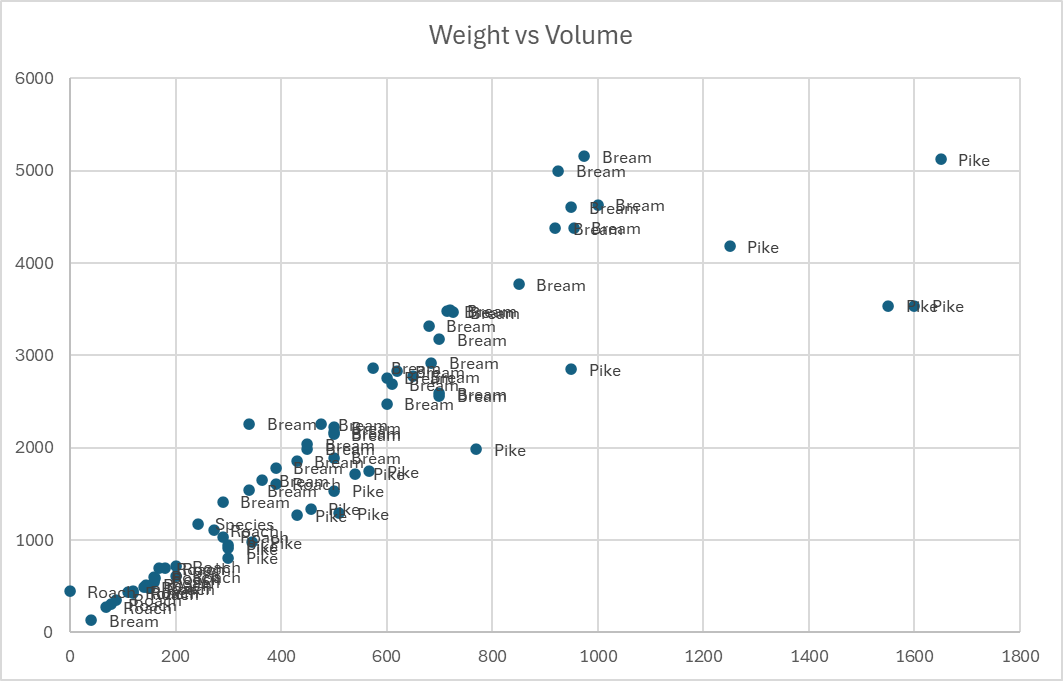

We could create a Linear Classifier that determines if, as our marine biologist collect fish, weigh them and measure them, determine if a fish is a ROACH, a BREAM, or a PIKE. The example below shows a flow diagram -- that for each sample of fish measured, we start to store the results of the three comparison Linear Classifiers.  That we do the determination based on BREAM vs ROACH; BREAM vs PIKE; and ROACH vs PIKE.  

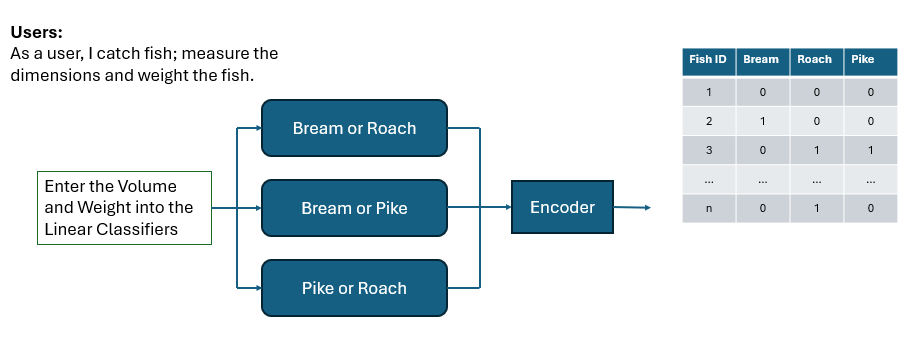

Two things could happen. First, the equations for the linear classifiers are generically now:
* w00*x + w10*y + b0 = classify(BREAM vs ROACH)
* w01*x + w11*y + b1 = classify(BREAM vs PIKE)
* w02*x + w12*y + b2 = classify(ROACH vs PIKE)

If we think of this as matrix math -- those could be combined into:  

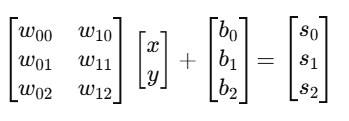

This is going to give us a maybe different look at a neural network than you are used to.  In the diagram below, the last circle isn't a SUM.  OUT is a voting system.  It counts the # of times we classified for each type of fish based on the pair-wise comparison.  Classifier neuron is what we would call a 1-layer Neural Network or a Perceptron.  2 -> 1.  

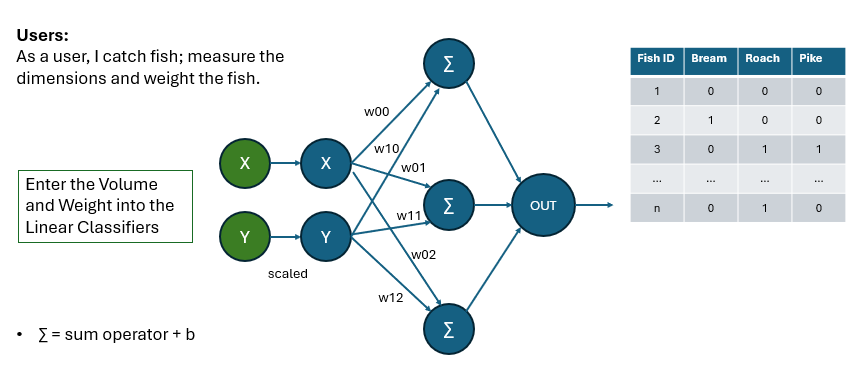

Let us dive into the code. 
In Part 1, Step 0, we load the species and encode the classes BREAM is 0, ROACH is 1 and PIKE is 2. 

In [ ]:
# ============================================================
# Part 1. Training a Pairwise Network
# ============================================================
"""
Trains 3 linear classifiers simultaneously:
  Bream vs Roach
  Bream vs Pike
  Roach vs Pike
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

# ============================================================
# Step 0. Load data
# ============================================================

df_load = load_dataset("scikit-learn/Fish")
df = df_load["train"].to_pandas()

df["Volume"] = df["Height"] * (df["Length2"] ** 2) * df["Width"]

# Keep only 3 species
df3 = df[df["Species"].isin(["Bream", "Roach", "Pike"])].copy()

X = df3[["Volume", "Weight"]].values

# Species → class index
species_map = {"Bream": 0, "Roach": 1, "Pike": 2}
y_class = df3["Species"].map(species_map).values



Part 1, Step 1 -- we start to create the y training data as masks. That as we sequence through the weights and volume data, we get the comparisons of 
* w00*x + w10*y + b0 = prediction(BREAM vs ROACH)
* w01*x + w11*y + b1 = prediction(BREAM vs PIKE)
* w02*x + w12*y + b2 = prediction(ROACH vs PIKE)

Part 1, Step 2 -- scales the input features.  X = all the combinations of weights and volumes by fish
Part 1, Step 3 -- we train the neural network.

In [ ]:
# ============================================================
# Step 1. Build pairwise labels
# ============================================================

# y[:,0] = Bream vs Roach
# y[:,1] = Bream vs Pike
# y[:,2] = Roach vs Pike

y = np.zeros((len(y_class), 3))

# Bream vs Roach
mask = np.isin(y_class, [0, 1])
y[mask, 0] = np.where(y_class[mask] == 0, +1, -1)

# Bream vs Pike
mask = np.isin(y_class, [0, 2])
y[mask, 1] = np.where(y_class[mask] == 0, +1, -1)

# Roach vs Pike
mask = np.isin(y_class, [1, 2])
y[mask, 2] = np.where(y_class[mask] == 1, +1, -1)

# ============================================================
# Step 2. Standardize features
# ============================================================

mu = X.mean(axis=0)
sigma = X.std(axis=0)
Xs = (X - mu) / sigma

# ============================================================
# Step 3. Train linear network (2 → 3)
# ============================================================

def sigmoid(z):
    z = np.clip(z, -60, 60)
    return 1.0 / (1.0 + np.exp(-z))

W = np.random.randn(2, 3) * 0.01
b = np.zeros(3)

lr = 0.15
epochs = 50

for _ in range(epochs):
    scores = Xs @ W + b          # (N,3)
    margins = y * scores
    mask = (y != 0)

    p = sigmoid(-margins)

    grad_W = np.zeros_like(W)
    grad_b = np.zeros_like(b)

    for k in range(3):
        mk = mask[:, k]
        grad_W[:, k] = np.mean(
            (-y[mk, k][:, None] * Xs[mk]) * p[mk, k][:, None],
            axis=0
        )
        grad_b[k] = np.mean(-y[mk, k] * p[mk, k])

    W -= lr * grad_W
    b -= lr * grad_b



Finally in Step 4 and Step 5 of Part 1, we plot the final results of the training.  That you can see the results of the process of doing 
1. feed forward,
2. loss calculation,
3. gradient calculation
4. back propogation
50 time (aka 50 epochs). 

In [ ]:
# ============================================================
# Step 4. Convert boundaries back to original scale
# ============================================================

W_orig = W / sigma[:, None]
b_orig = b - (mu @ W_orig)

# ============================================================
# Step 5. Final plot (ONLY final result)
# ============================================================

plt.figure(figsize=(9, 6))

for species, idx in species_map.items():
    pts = df3[y_class == idx]
    plt.scatter(
        pts["Volume"],
        pts["Weight"],
        label=species
    )

x_min, x_max = X[:, 0].min(), X[:, 0].max()
y_min, y_max = X[:, 1].min(), X[:, 1].max()
xx = np.linspace(x_min, x_max, 300)

labels = [
    "Bream vs Roach",
    "Bream vs Pike",
    "Roach vs Pike"
]

for k in range(3):
    w1, w2 = W_orig[:, k]
    bb = b_orig[k]

    if abs(w2) > 1e-8:
        yy = -(w1 * xx + bb) / w2
        plt.plot(xx, yy, linestyle="--", label=labels[k])

plt.xlabel("Volume")
plt.ylabel("Weight")
plt.title("Final Pairwise Linear Decision Boundaries")
plt.legend()
plt.show()

W_final = W.copy()    # shape (2,3)
b_final = b.copy()    # shape (3,)

# 2 MAKING A PREDICTION
When you look at the resulting prediction network, Bream vs Roach and Roach vs Pike are clearer divides in the data.  But notice -- Bream vs Pike's line isn't as clear.  That is because Pike is made of sparse, mostly large volume and higher weight. Pike overlaps Bream along a slanted direction.

Below is the User Input Prediction model.  And as you will see, it is possible for an entry to end up predicting that a fish is all three -- a BREAM, a ROACH and a PIKE.

In [ ]:
# ============================================================
# Part 2. User Input → Prediction (Pairwise Network)
# ============================================================

# ------------------------------------------------------------
# STEP 1: Valid input ranges (from training data)
# ------------------------------------------------------------
length_min, length_max = df3['Length2'].min(), df3['Length2'].max()
width_min,  width_max  = df3['Width'].min(),  df3['Width'].max()
height_min, height_max = df3['Height'].min(), df3['Height'].max()
weight_min, weight_max = df3['Weight'].min(), df3['Weight'].max()

print("Enter values within these ranges:")
print(f"  Length : [{length_min:.1f}, {length_max:.1f}]")
print(f"  Width  : [{width_min:.1f},  {width_max:.1f}]")
print(f"  Height : [{height_min:.1f}, {height_max:.1f}]")
print(f"  Weight : [{weight_min:.1f}, {weight_max:.1f}]")

# ------------------------------------------------------------
# STEP 2: User input
# ------------------------------------------------------------

length = float(input("Length: "))
width  = float(input("Width : "))
height = float(input("Height: "))
weight = float(input("Weight: "))

assert length_min <= length <= length_max
assert width_min  <= width  <= width_max
assert height_min <= height <= height_max
assert weight_min <= weight <= weight_max

# ------------------------------------------------------------
# STEP 3: Feature construction
# ------------------------------------------------------------
volume = height * (length ** 2) * width
x_user = np.array([volume, weight])

x_user_std = (x_user - mu) / sigma

# ------------------------------------------------------------
# STEP 4: Pairwise scores
# ------------------------------------------------------------
scores = x_user_std @ W_final + b_final
# scores[0] → Bream vs Roach
# scores[1] → Bream vs Pike
# scores[2] → Roach vs Pike

# ------------------------------------------------------------
# STEP 5: Majority vote
# ------------------------------------------------------------
votes = {"Bream": 0, "Roach": 0, "Pike": 0}

# Bream vs Roach
if scores[0] >= 0:
    votes["Bream"] += 1
else:
    votes["Roach"] += 1

# Bream vs Pike
if scores[1] >= 0:
    votes["Bream"] += 1
else:
    votes["Pike"] += 1

# Roach vs Pike
if scores[2] >= 0:
    votes["Roach"] += 1
else:
    votes["Pike"] += 1

prediction = max(votes, key=votes.get)

# Optional confidence proxy
confidence = votes[prediction] / 2.0   # max = 1.0 (wins both pairwise tests)

# ------------------------------------------------------------
# STEP 6: Output
# ------------------------------------------------------------
print("\n--- Multiclass Prediction (Pairwise Network) ---")
print(f"Volume computed : {volume:.2f}")
print(f"Pairwise scores :")
print(f"  Bream vs Roach : {scores[0]:.3f}")
print(f"  Bream vs Pike  : {scores[1]:.3f}")
print(f"  Roach vs Pike  : {scores[2]:.3f}")

print("\nVotes:", votes)
print(f"Prediction : {prediction}")
print(f"Confidence : {confidence:.2f}")

# 3 Classic Neural Network
In Part 2, we used three 2->1 Single-layer neural networks (aka a Perceptron) (aka a Linear Classifier), sent it to a Voting System, and made a final decision.   

In this section, we are going to create our first multilayer neural network.  It will be a 2 -> H -> 3 network -- where 2 is the input of Volume and Weight, H is the hidden layer of any arbitrary number of nodes, and 3 is the output layer - a separate prediction of BREAM, ROACH, and PIKE. 

If you would like to run standalone, remove the lines ### from above

In [ ]:
"""\
Classic Neural Network version of your pairwise linear system.

What changes:
- Instead of 3 pairwise binary heads with labels in {-1,+1,0}, we train a *single* 3-class
  classifier (Bream/Roach/Pike) with a small MLP: 2 → H → 3 and softmax cross-entropy.
- You still get decision regions; plotting boundaries is done by evaluating the network on a grid.

Run end-to-end as a single script; remove the three quotes and from above if running stand-alone.
"""

### from above import numpy as np
### from above import matplotlib.pyplot as plt
### from above from datasets import load_dataset

# ============================================================
# Step 0. Load data
# ============================================================
### from above df_load = load_dataset("scikit-learn/Fish")
### from above df = df_load["train"].to_pandas()

# Feature engineering
### from above df["Volume"] = df["Height"] * (df["Length2"] ** 2) * df["Width"]

# Keep only 3 species
### from aboved f3 = df[df["Species"].isin(["Bream", "Roach", "Pike"])].copy()

X2 = df3[["Volume", "Weight"]].values.astype(np.float64)

species_map = {"Bream": 0, "Roach": 1, "Pike": 2}
idx_to_species = {v: k for k, v in species_map.items()}

y2 = df3["Species"].map(species_map).values.astype(np.int64)  # (N,)

# ============================================================
# Step 1. Standardize features
# ============================================================
mu2 = X2.mean(axis=0)
sigma2 = X2.std(axis=0)
Xs2 = (X2 - mu2) / (sigma2 + 1e-12)

# ============================================================
# Step 2. Define a small MLP: 2 → H → 3
# ============================================================
def relu(z):
    return np.maximum(0.0, z)

def relu_grad(z):
    return (z > 0).astype(z.dtype)

def softmax(logits):
    # stable softmax
    z = logits - logits.max(axis=1, keepdims=True)
    ez = np.exp(z)
    return ez / (ez.sum(axis=1, keepdims=True) + 1e-12)

# Hyperparams
H = 128
lr = 0.08
epochs = 600
weight_decay = 1e-4

rng = np.random.default_rng(0)

# He init for ReLU
W1 = rng.normal(0, np.sqrt(2 / 2), size=(2, H))
b1 = np.zeros(H)
W2 = rng.normal(0, np.sqrt(2 / H), size=(H, 3))
b2 = np.zeros(3)

N = Xs2.shape[0]

# ============================================================
# Step 3. Train with full-batch gradient descent
# ============================================================
for _ in range(epochs):
    # Forward
    z1 = Xs2 @ W1 + b1            # (N,H)
    h1 = relu(z1)                # (N,H)
    logits = h1 @ W2 + b2        # (N,3)
    probs = softmax(logits)      # (N,3)

    # Cross-entropy loss gradient
    # dL/dlogits = (probs - one_hot) / N
    one_hot = np.zeros_like(probs)
    one_hot[np.arange(N), y2] = 1.0
    dlogits = (probs - one_hot) / N

    # Backprop
    dW2 = h1.T @ dlogits + weight_decay * W2
    db2 = dlogits.sum(axis=0)

    dh1 = dlogits @ W2.T
    dz1 = dh1 * relu_grad(z1)

    dW1 = Xs2.T @ dz1 + weight_decay * W1
    db1 = dz1.sum(axis=0)

    # Update
    W2 -= lr * dW2
    b2 -= lr * db2
    W1 -= lr * dW1
    b1 -= lr * db1

# ============================================================
# Step 4. Evaluate training accuracy
# ============================================================
logits = relu(Xs2 @ W1 + b1) @ W2 + b2
pred = np.argmax(logits, axis=1)
acc = (pred == y2).mean()
print(f"Train accuracy: {acc*100:.1f}%")

# ============================================================
# Step 5. Plot decision regions + points
# ============================================================
plt.figure(figsize=(9, 6))

# Scatter points
for species, idx in species_map.items():
    pts = df3[y2 == idx]
    plt.scatter(pts["Volume"], pts["Weight"], label=species, s=35)

# Decision regions on a grid
x_min, x_max = X2[:, 0].min(), X2[:, 0].max()
y_min, y_max = X2[:, 1].min(), X2[:, 1].max()

# Make the grid a bit padded so boundaries are visible
pad_x = 0.05 * (x_max - x_min)
pad_y = 0.05 * (y_max - y_min)

xg = np.linspace(x_min - pad_x, x_max + pad_x, 400)
yg = np.linspace(y_min - pad_y, y_max + pad_y, 400)
XX, YY = np.meshgrid(xg, yg)

grid = np.c_[XX.ravel(), YY.ravel()]

# Standardize grid using training mu/sigma
grid_s = (grid - mu2) / (sigma2 + 1e-12)

g_logits = relu(grid_s @ W1 + b1) @ W2 + b2

g_pred = np.argmax(g_logits, axis=1).reshape(XX.shape)

# Draw class boundaries by showing regions; keep it subtle
plt.contourf(XX, YY, g_pred, levels=[-0.5, 0.5, 1.5, 2.5], alpha=0.15)

# Optionally, contour lines where classes switch
plt.contour(XX, YY, g_pred, levels=[0.5, 1.5], linewidths=1)

plt.xlabel("Volume")
plt.ylabel("Weight")
plt.title(f"MLP (2 → {H} → 3) Softmax Decision Regions")
plt.legend()
plt.show()

# Expose final params if you want to reuse them later
params = {
    "mu": mu2,
    "sigma": sigma2,
    "W1": W1,
    "b1": b1,
    "W2": W2,
    "b2": b2,
    "species_map": species_map,
}

# ------------------------------------------------------------
# Notes / quick tweaks:
# - Increase H for more flexible boundaries (try 16 or 32).
# - If it overfits (rare here), increase weight_decay.
# - If training is unstable, lower lr (e.g., 0.03) or epochs.
# ------------------------------------------------------------


The above code does both the training of the model and visualizing the decision boundary.  As you can see, a 2-layer Neural Network is capable of creating non-linear decisions. 

If we think of computation; there is a difference in the multiply and accumumlate (MAC): 

**1) Pairwise linear** (your 2 → 3 linear heads)
You compute scores = X @ W + b where W is (2×3).
2×3 dot products, each dot is length 2
→ MACs = 2·3 = 6

Adds/bias are small (3 adds)

If you also include the sigmoid (for training loss / probabilities), that’s 3 sigmoids (exp-heavy), but the dominant “linear algebra” part is still tiny.

Inference cost (linear part): ~6 MACs/sample.

**2) 2-layer MLP** (2 → H → 3 with ReLU)
Hidden pre-activation:  X(2)⋅W1(2×H)
     → MACs = 2·H

Output layer: h(H)⋅W2(H×3)
     → MACs = H·3 = 3H

ReLU is cheap (just comparisons)
Inference cost: 2H+3H = ~5H MACs/sample.

The 2-layer Multilayer model scales by H. So...H=8: 40 MACs | H=16: 80 MACs | H=32: 160 MACs. 

**Two Takeaways:** 
- The multilayer NN model is going to perform better than the Pairwise Linear method.
- The multilayer NN model is takes more computations.
